# TEK HEAD

In [ ]:
# @title
# # @title
# from prompt_toolkit.filters.cli import ViInsertMultipleMode
# from IPython.core.debugger import Tracer
# import torch
# import torch.nn as nn
# from torch.nn import functional as F
# torch.manual_seed(1337)
# # 1. Çok ufak veri setimiz
# df = [
#     "kral sarayda yaşar",
#     "kraliçe sarayda yaşar",
#     "adam dışarıda yürür",
#     "kadın dışarıda yürür"
# ]

# # Benzersiz kelimeleri bulalım (vocabulary)
# # cümleleri boşluklara göre ayırıp benzersiz kelime listesi oluşturak
# words = set(" ".join(df).split())

# # kelimelere birer sayısal ID (index) verelim
# word_to_ix = {word:i for i, word in enumerate(words)}
# ix_to_word = {i:word for i, word in enumerate(words)}

# embeddings = []
# for i in range(len(words)):
#     word_emb_one_hot = torch.zeros(len(words))
#     word_emb_one_hot[i] += 1
#     embeddings.append(word_emb_one_hot)

# embeddings = torch.stack(embeddings)
# embedding_dim = 4
# weights = torch.rand(len(words), embedding_dim)

# # Tüm sözlüğün genel embedding matrisi (Boyut: 6 x 4)
# all_word_embeddings = embeddings @ weights

# # --- Positional Encoding (Boyut: 3 x 4) ---
# max_len = 3
# pos_enc = torch.zeros(max_len, embedding_dim)

# for pos in range(max_len):
#     for i in range(embedding_dim):
#         if i % 2 == 0:
#             pos_enc[pos, i] = torch.sin(torch.tensor(pos, dtype=torch.float32) / 10000**(i/embedding_dim))
#         else:
#             pos_enc[pos, i] = torch.cos(torch.tensor(pos, dtype=torch.float32) / 10000**((i-1)/embedding_dim))

# # --- ÇÖZÜM ADIMI: Bir cümle seçiyoruz ---
# ornek_cumle = "kral sarayda yaşar"

# # Cümledeki kelimelerin ID'lerini alıyoruz (Örn: [2, 0, 5])
# cumle_ix = [word_to_ix[kelime] for kelime in ornek_cumle.split()]

# # Genel matristen SADECE bu 3 kelimenin embedding'ini çekiyoruz (Boyut: 3 x 4 oluyor)
# cumle_embeddings = all_word_embeddings[cumle_ix]

# # Input matrisi: (sequence_length=3, embedding_dim=4)
# transformer_girdisi = cumle_embeddings + pos_enc

# print("="*60)
# print("             CELL 1: SINGLE-HEAD ENCODER")
# print("="*60)
# print(f"\nGiriş Matrisi Shape: {transformer_girdisi.shape}")

# # --- SELF ATTENTION ---

# W_Q = torch.rand(embedding_dim, embedding_dim, requires_grad=True)
# W_K = torch.rand(embedding_dim, embedding_dim, requires_grad=True)
# W_V = torch.rand(embedding_dim, embedding_dim, requires_grad=True)

# Q = transformer_girdisi @ W_Q
# K = transformer_girdisi @ W_K
# V = transformer_girdisi @ W_V

# affinity = Q @ K.T

# # Scaled Dot-Product Attention # Attention(Q,K,V) = softmax(Q*Kt / head_size**0.5) @ V
# softed = torch.softmax(affinity/embedding_dim**0.5, dim=1)

# attention_output = softed @ V

# # --- RESIDUAL CONNECTION (ADD) ADIMI ---
# # x + F(x)
# residual_output = transformer_girdisi + attention_output

# # --- LAYER NORMALIZATION ---

# # 1. Satır bazında ortalama (mean) --> Her satırın kendi ortalaması
# # dim = -1 satır boyunca hesapla demek, keepdim = True ise boyutu (3,1) yapar ki rahatça çıkaralım
# mean = residual_output.mean(dim=-1, keepdim=True)

# # 2. Satır bazında varyans
# variance = residual_output.var(dim=-1, keepdim=True) # BatchNorm'da popülasyon varyansı (n) kullanılır, örneklem varyansı: (n-1) değil.

# # 3. Normalizasyon
# epsilon = 1e-5
# normalized = (residual_output - mean) / (variance + epsilon)**0.5

# # SCALE & SHIFT (Gamma ve Beta)
# # Her bir embedding boyutu için (4 adet) öğrenilebilir parametre tanımlıyoruz
# gamma = torch.ones(embedding_dim) # 1'lerle başlar
# beta = torch.zeros(embedding_dim) # 0'larla başlar

# # Nihai LayerNorm Çıktısı !
# layernorm_output = gamma * normalized + beta

# # --- FEED FORWARD ---
# # Katman 1: Boyutu 4'ten 8'e çıkaracak ağırlıklar ve bias
# W_ff1 = torch.rand(4, 8, requires_grad=True)
# b_ff1 = torch.zeros(1, 8, requires_grad=True) # Bias eklemek iyidir

# # Katman 2: Boyutu 8'den tekrar 4'e indirecek ağırlıklar ve bias
# W_ff2 = torch.rand(8, 4, requires_grad=True)
# b_ff2 = torch.zeros(1, 4, requires_grad=True)

# # Formülü uygulayalım
# ffn_output = layernorm_output @ W_ff1 + b_ff1
# ffn_output = F.gelu(ffn_output) # GELU ' dan geçirelim. ReLU gibi bisey
# ffn_output = ffn_output @ W_ff2 + b_ff2
# print("FFN Output: \n",ffn_output)

# # Tıpkı Self-Attention'dan sonra yaptığımız gibi, orijinal mimaride
# # bu Feed-Forward katmanının da etrafında bir "Add & Norm" (Residual + LayerNorm)
# # yapısı vardır.

# # 1. ADD (Residual) -> FFN girdisi + FFN çıktısı
# final_residual = layernorm_output + ffn_output

# # 2. NORM (LayerNorm) -> Az önce yukarıda yazdıgım satır bazlı normalizasyonun aynısı
# final_mean = final_residual.mean(dim=-1, keepdim=True)
# final_variance = final_residual.var(dim=-1, unbiased=False, keepdim=True)

# # Aynı gamma ve beta mantıgıyla son katman normalizasyonu
# block_output = (final_residual - final_mean) / (final_variance + epsilon)**0.5
# block_output = gamma * block_output + beta

# print("\n=== SINGLE-HEAD 1. TRANSFORMER BLOĞUNUN NİHAİ ÇIKTISI ===\n",block_output)

### "Multi-Head" (Çok Kafalı) Olunca Ne Değişiyor?

Josh Starmer’ın o ünlü benzetmesiyle düşünelim: Bir cümleye tek bir kafayla bakarsan, o kafa sadece **tek bir ilişki türüne** odaklanabilir (Örneğin: Sadece özne-yüklem ilişkisine veya sadece dil bilgisi uyumuna).

Ama eğer modelimiz **Multi-Head Attention (Çok Kafalı Dikkat)** kullanırsa (örneğin 2 kafalı veya makaledeki gibi 8 kafalı):

- **1. Kafa:** _"Kral"_ ile _"sarayda"_ arasındaki **mekan/konum** ilişkisine odaklanır.
    
- **2. Kafa:** _"Kral"_ ile _"yaşar"_ arasındaki **eylem/özne** ilişkisine odaklanır.
    

### Bunu Kodda Nasıl Yapardık? (İşin Sırrı)

Biz `embedding_dim = 4` seçtik ya; eğer **2 kafalı (2-Head)** bir mimari yapmak isteseydik, her bir kafanın boyutu (`head_size` veya makaledeki adıyla $d_k$) şu şekilde hesaplanacaktı:

$$\text{head_size} = \frac{\text{embedding_dim}}{\text{num_heads}} = \frac{4}{2} = 2$$
---
Yani bizim $W_Q, W_K, W_V$ ağırlık matrislerimiz $4 \times 4$ olmak yerine, her bir kafa için **$4 \times 2$** boyutunda olacaktı:

- **Kafa 1 için:** $W_{Q1}, W_{K1}, W_{V1}$ (Boyutları $4 \times 2$) $\rightarrow$ Kendine ait bir `attention_output1` ($3 \times 2$) üretecek.
    
- **Kafa 2 için:** $W_{Q2}, W_{K2}, W_{V2}$ (Boyutları $4 \times 2$) $\rightarrow$ Kendine ait bir `attention_output2` ($3 \times 2$) üretecek.
    

En son bu iki kafanın ürettiği $3 \times 2$'lik matrisleri yan yana yapıştıracaktık (Concatenate):

$[3 \times 2] \text{ ve } [3 \times 2] \rightarrow [3 \times 4]$

Ve bom! Yine başladığımız boyuta ($3 \times 4$) geri dönmüş olacaktık. İşte makaledeki o karmaşık görünen Multi-Head yapısının bütün numarası bu yan yana yapıştırma işleminden ibaret.

# SOL TARAFI İNŞA EDELİM !! (ENCODER)


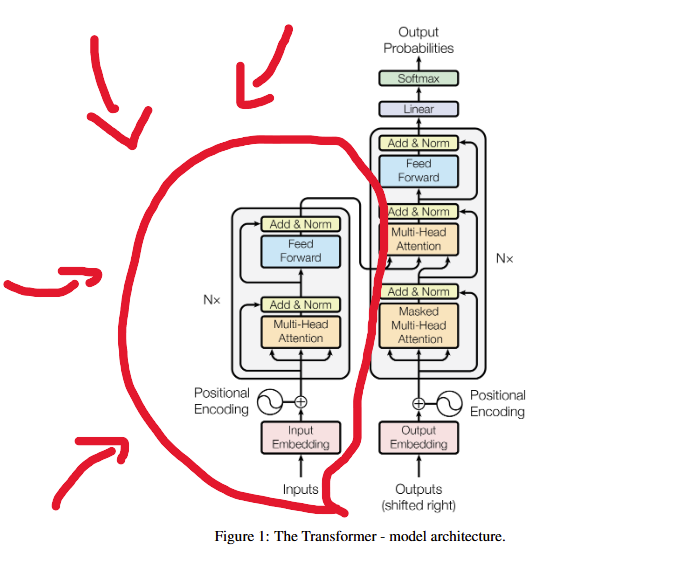

In [ ]:
import torch
import torch.nn as nn
from torch.nn import functional as F
torch.manual_seed(1337)
# 1. Çok ufak veri setimiz
df = [
    "kral sarayda yaşar",
    "kraliçe sarayda yaşar",
    "adam dışarıda yürür",
    "kadın dışarıda yürür"
]

# Benzersiz kelimeleri bulalım (vocabulary)
words = set(" ".join(df).split())

# kelimelere birer sayısal ID (index) verelim
word_to_ix = {word:i for i, word in enumerate(words)}
ix_to_word = {i:word for i, word in enumerate(words)}

embeddings = []
for i in range(len(words)):
    word_emb_one_hot = torch.zeros(len(words))
    word_emb_one_hot[i] += 1
    embeddings.append(word_emb_one_hot)

embeddings = torch.stack(embeddings)
embedding_dim = 4
weights = torch.rand(len(words), embedding_dim)

# Tüm sözlüğün genel embedding matrisi (Boyut: 6 x 4)
all_word_embeddings = embeddings @ weights

# --- Positional Encoding (Boyut: 3 x 4) ---
max_len = 3
pos_enc = torch.zeros(max_len, embedding_dim)

for pos in range(max_len):
    for i in range(embedding_dim):
        if i % 2 == 0:
            pos_enc[pos, i] = torch.sin(torch.tensor(pos, dtype=torch.float32) / 10000**(i/embedding_dim))
        else:
            pos_enc[pos, i] = torch.cos(torch.tensor(pos, dtype=torch.float32) / 10000**((i-1)/embedding_dim))

# --- ÇÖZÜM ADIMI: Bir cümle seçiyoruz ---
ornek_cumle = "kral sarayda yaşar"

# Cümledeki kelimelerin ID'lerini alıyoruz (Örn: [2, 0, 5])
cumle_ix = [word_to_ix[kelime] for kelime in ornek_cumle.split()]

# Genel matristen SADECE bu 3 kelimenin embedding'ini çekiyoruz (Boyut: 3 x 4 oluyor)
cumle_embeddings = all_word_embeddings[cumle_ix]

# Input matrisi: (sequence_length=3, embedding_dim=4)
transformer_girdisi = cumle_embeddings + pos_enc

# =====================================================================
# ADIM 1: MULTI-HEAD ATTENTION (2 HEADS)
# =====================================================================

# --- MULTI-HEAD ATTENTION'A GEÇELIM ---
print("="*60)
print("             CELL 2: MULTI-HEAD ENCODER")
print("="*60)
num_heads = 2
head_size = embedding_dim // num_heads # (4 // 2 = 2)

# KAFA 1 için parametreler (Boyut: 4 x 2)
W_Q1 = torch.rand(4, head_size, requires_grad=True)
W_K1 = torch.rand(4, head_size, requires_grad=True)
W_V1 = torch.rand(4, head_size, requires_grad=True)

# KAFA 2 için parametreler (Boyut: 4 x 2)
W_Q2 = torch.rand(4, head_size, requires_grad=True)
W_K2 = torch.rand(4, head_size, requires_grad=True)
W_V2 = torch.rand(4, head_size, requires_grad=True)

Q1 = transformer_girdisi @ W_Q1
K1 = transformer_girdisi @ W_K1
V1 = transformer_girdisi @ W_V1

affinity = Q1 @ K1.T
softed = torch.softmax(affinity / head_size**0.5, dim=1)
head1_out = softed @ V1

Q2 = transformer_girdisi @ W_Q2
K2 = transformer_girdisi @ W_K2
V2 = transformer_girdisi @ W_V2

affinity2 = Q2 @ K2.T
softed2 = torch.softmax(affinity2 / head_size**0.5, dim=1)
head2_out = softed2 @ V2

# Şimdi bu iki kafayı birleştirme (concatenation) zamanı. Makaledeki şemaya göre
# kafaların çıktıları yan yana yapıştırılır ve ardından doğrusal bir projeksiyon
# katmanıyla (W0 matrisiyle) çarpılarak nihai Multi-Head Attention çıktısı üretilir.

# --- 1. Adım: Kafaları yan yana yapıştırmak ---
multi_head_concat = torch.cat((head1_out, head2_out), dim=-1) # (3, 2), (3, 2) yan yana koyduk

# --- 2. Adım: Nihai Çıkış Ağırlık Matrisi (W0) ---
# Makalede kafaları yan yana yapıştırdıktan sonra, bu kafaların bilgilerini birbirine harmanlamak
# için onu son bir öğrenilebilir ağırlık matrisiyle çarpın der. İşte o matris W0 (output weights) matrisidir.
W_0 = torch.rand(embedding_dim, embedding_dim, requires_grad=True)

# --- 3. Adım: Matrisleri çarp ve nihai attention çıktısını elde et
attention_output = multi_head_concat @ W_0
print("Multi-Head Attention Output: \n", attention_output)

# =====================================================================
# ADIM 2: FIRST ADD & NORM (ATTENTION ETRAFINDAKİ RESIDUAL)
# =====================================================================
# --- RESIDUAL CONNECTION (ADD) ADIMI ---
# x + F(x)
residual_output = transformer_girdisi + attention_output

# --- LAYER NORMALIZATION ---
# 1. Satır bazında ortalama (mean) --> Her satırın kendi ortalaması
# dim = -1 satır boyunca hesapla demek, keepdim = True ise boyutu (3,1) yapar ki rahatça çıkaralım
mean = residual_output.mean(dim=-1, keepdim=True)

# 2. Satır bazında varyans
variance = residual_output.var(dim=-1, keepdim=True) # BatchNorm'da popülasyon varyansı (n) kullanılır, örneklem varyansı: (n-1) değil.

# 3. Normalizasyon
epsilon = 1e-5
normalized = (residual_output - mean) / (variance + epsilon)**0.5

# SCALE & SHIFT (Gamma ve Beta)
gamma = torch.ones(embedding_dim) # 1'lerle başlar
beta = torch.zeros(embedding_dim) # 0'larla başlar

# Nihai LayerNorm Çıktısı !
layernorm_output = gamma * normalized + beta

# =====================================================================
# ADIM 3: FEED FORWARD NETWORK (FFN)
# =====================================================================

# --- FEED FORWARD ---
# Katman 1: Boyutu 4'ten 8'e çıkaracak ağırlıklar ve bias
W_ff1 = torch.rand(4, 8, requires_grad=True)
b_ff1 = torch.zeros(1, 8, requires_grad=True) # Bias eklemek iyidir

# Katman 2: Boyutu 8'den tekrar 4'e indirecek ağırlıklar ve bias
W_ff2 = torch.rand(8, 4, requires_grad=True)
b_ff2 = torch.zeros(1, 4, requires_grad=True)

# Formülü uygulayalım
ffn_output = layernorm_output @ W_ff1 + b_ff1
ffn_output = F.gelu(ffn_output) # GELU ' dan geçirelim. ReLU gibi bisey
ffn_output = ffn_output @ W_ff2 + b_ff2
print("\nFFN Output: \n", ffn_output)

# =====================================================================
# ADIM 4: SECOND ADD & NORM (FFN ETRAFINDAKİ RESIDUAL)
# =====================================================================

# 1. ADD (Residual) -> FFN girdisi + FFN çıktısı
final_residual = layernorm_output + ffn_output

# 2. NORM (LayerNorm) -> Az önce yukarıda yazdıgım satır bazlı normalizasyonun aynısı
final_mean = final_residual.mean(dim=-1, keepdim=True)
final_variance = final_residual.var(dim=-1, unbiased=False, keepdim=True)

# Aynı gamma ve beta mantıgıyla son katman normalizasyonu
encoder_output = (final_residual - final_mean) / (final_variance + epsilon)**0.5
encoder_output = gamma * encoder_output + beta

print("\n=== MULTI-HEAD ENCODER NİHAİ MATRİS ÇIKTISI ===")
print(encoder_output)

             CELL 2: MULTI-HEAD ENCODER
Multi-Head Attention Output: 
 tensor([[7.6871, 6.5257, 5.6980, 4.8623],
        [7.6977, 6.5421, 5.7171, 4.8854],
        [7.7680, 6.6119, 5.7891, 4.9497]], grad_fn=<MmBackward0>)

FFN Output: 
 tensor([[0.4761, 0.5472, 0.5630, 0.8179],
        [0.6069, 0.7385, 0.8138, 0.9898],
        [0.5077, 0.8916, 0.8856, 0.9603]], grad_fn=<AddBackward0>)

=== MULTI-HEAD ENCODER NİHAİ MATRİS ÇIKTISI ===
tensor([[ 1.0069,  0.9745, -1.1823, -0.7991],
        [ 1.4642,  0.3776, -1.0134, -0.8284],
        [ 1.7078, -0.7710, -0.6268, -0.3101]], grad_fn=<AddBackward0>)


# ŞEMANIN SAĞ TARAFINA GEÇELİM !!! (DECODER) 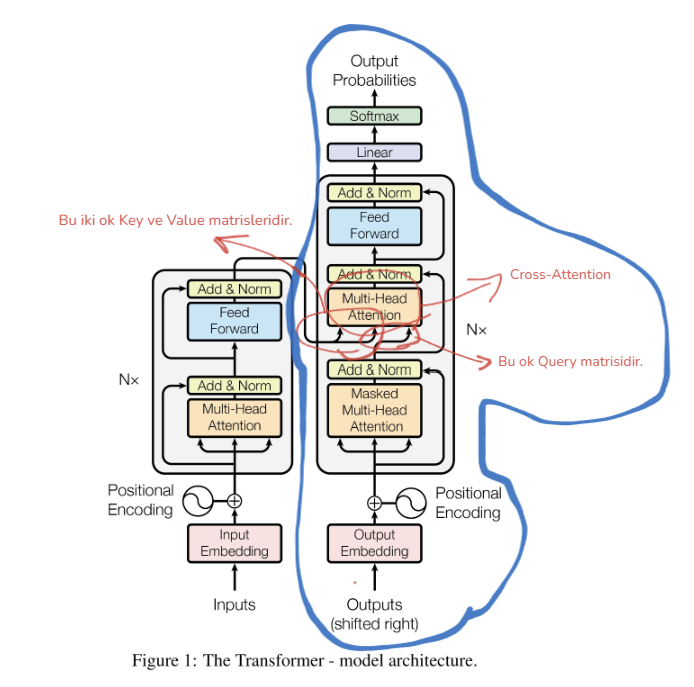

In [ ]:
# Decoder'a giren hedef cümlenin de şimdilik 3 kelime olduğunu varsayalım
# Sol taraftaki yapıları taklit ederek decoder girdisini simüle ediyoruz

# Tekrar hatırlayalım: num_heads = 2, head_size = 2, seq_len = 3
decoder_girdisi = cumle_embeddings + pos_enc
seq_len = 3 # cümle uzunlugumuz: ("Kral sarayda yaşar")
head_size = 2


# =====================================================================
# ADIM 1: MASKED MULTI-HEAD ATTENTION (Decoder'ın İlk Katmanı)
# =====================================================================

# Kafa 1 için yeni Decoder parametreleri (Boyut: 4 x 2)
W_Q1_dec = torch.rand(4, head_size, requires_grad=True)
W_K1_dec = torch.rand(4, head_size, requires_grad=True)
W_V1_dec = torch.rand(4, head_size, requires_grad=True)

# --- 1. Adım: Q1, K1 ve V1 matrislerini "decoder_girdisi" kullanarak elde edicez ---
Q1_dec = decoder_girdisi @ W_Q1_dec
K1_dec = decoder_girdisi @ W_K1_dec
V1_dec = decoder_girdisi @ W_V1_dec

# --- 2. Adım: Affinity matrisini hesaplayalım --- (Q1_dec @ K1_dec.T)
affinity1_dec = Q1_dec @ K1_dec.T

# --- 3. Adım: Üçgen maskesi ---
mask = torch.tril(torch.ones(seq_len, seq_len), diagonal=0)

# Mask'ın 0 oldugu yerleri masked_fill ile "-inf" yapalım. -inf yapınca softmax 0 yapacak
masked_affinity1 = affinity1_dec.masked_fill(mask == 0, float("-inf"))

# --- 4. Adım: Maskelenmiş affinity'i head_size**0.5 ile ölçeklendirip satır bazında softmax'ten geçirelim ---
softed1_dec = torch.softmax(masked_affinity1/head_size**0.5, dim=1)
print("Softmaxed decoder output: \n", softed1_dec)

# --- 5. Adım: Sonucu V ile (V1_dec) ile çarparak ilk kafanın maskeli çıktısını elde edelim ---
head1_dec_out = softed1_dec @ V1_dec
print("Masked output of our first head: \n",head1_dec_out)

# =========================================================================
#                       İKİNCİ KAFAYA GEÇELİM
# =========================================================================
W_Q2_dec = torch.rand(4, head_size, requires_grad=True)
W_K2_dec = torch.rand(4, head_size, requires_grad=True)
W_V2_dec = torch.rand(4, head_size, requires_grad=True)

# İlk kafa için uyguladığımız işlemleri uygulayalım
Q2_dec = decoder_girdisi @ W_Q2_dec
K2_dec = decoder_girdisi @ W_K2_dec
V2_dec = decoder_girdisi @ W_V2_dec

affinity2_dec = Q2_dec @ K2_dec.T

masked_affinity2 = affinity2_dec.masked_fill(mask == 0, float("-inf"))
softed2_dec = torch.softmax(masked_affinity2/head_size**0.5, dim=1)
head2_dec_out = softed2_dec @ V2_dec

# ========================================================================
#                    BİRLEŞTİRME VE PROJEKSİYON
# ========================================================================
multi_head_concat_dec = torch.cat((head1_dec_out, head2_dec_out),dim=-1)
W0_dec = torch.rand(embedding_dim, embedding_dim, requires_grad=True)
masked_attention_output = multi_head_concat_dec @ W0_dec
print("Masked Multi-Head Attention Çıktısı (Boyut: 3x4): \n", masked_attention_output)

# =========================================================================
#                    Add & Norm (Residual + LayerNorm)
# =========================================================================
# x + F(x)
residual_output2 = decoder_girdisi + masked_attention_output

# --- LAYER NORMALIZATION ---
# 1. Satır bazında ortalama (mean) --> Her satırın kendi ortalaması
# dim = -1 satır boyunca hesapla demek, keepdim = True ise boyutu (3,1) yapar ki rahatça çıkaralım
mean2 = residual_output2.mean(dim=-1, keepdim=True)

# 2. Satır bazında varyans
variance2 = residual_output2.var(dim=-1, keepdim=True) # BatchNorm'da popülasyon varyansı (n) kullanılır, örneklem varyansı: (n-1) değil.

# 3. Normalizasyon
epsilon = 1e-5
normalized2 = (residual_output2 - mean2) / (variance2 + epsilon)**0.5

# SCALE & SHIFT (Gamma ve Beta)
gamma = torch.ones(embedding_dim) # 1'lerle başlar
beta = torch.zeros(embedding_dim) # 0'larla başlar

# Nihai LayerNorm Çıktısı !
layernorm_output2 = gamma * normalized2 + beta
print("LayerNorm çıktımız: \n",layernorm_output2)

# =========================================================================
#                           CROSS-ATTENTİON KATMANI
# =========================================================================
# Geldik o decoder bloğunun ikinci sarı kutusuna. Şemada sadece "Multi-Head Attention"
# yazıyor ama aslında orası Cross-Attention. (Sol tarafla sağı bağlıyo cross-attention)

# --- KAFA 1 PARAMETRELERİ VE HESAPLAMALARI ---
W_Q1_cross = torch.rand(4, head_size, requires_grad=True)
W_K1_cross = torch.rand(4, head_size, requires_grad=True)
W_V1_cross = torch.rand(4, head_size, requires_grad=True)

Q1_cross = layernorm_output2 @ W_Q1_cross
K1_cross = encoder_output @ W_K1_cross
V1_cross = encoder_output @ W_V1_cross

affinity1_cross = Q1_cross @ K1_cross.T

# Cross-attention'da maskeleme yoktur çünkü decoder, encoder'ın tüm çıktılarını
# güvenle görebilir. Encoder girişi zaten tamamen bilinen bilgidir; bu yüzden geleceği
# gizlemeye gerek yoktur. Sadece varsa padding token'ları maskelenir.
softed1_cross = torch.softmax(affinity1_cross/head_size**0.5, dim=1)
head1_cross_out = softed1_cross @ V1_cross

# KAFA 2 PARAMETRELERİ VE HESAPLAMALARI ---
# Aynı işlemleri kafa 2 içinde uygulayalım
W_Q2_cross = torch.rand(4, head_size, requires_grad=True)
W_K2_cross = torch.rand(4, head_size, requires_grad=True)
W_V2_cross = torch.rand(4, head_size, requires_grad=True)

Q2_cross = layernorm_output2 @ W_Q2_cross
K2_cross = encoder_output @ W_K2_cross
V2_cross = encoder_output @ W_V2_cross

affinity2_cross = Q2_cross @ K2_cross.T
softed2_cross = torch.softmax(affinity2_cross/head_size**0.5, dim=1)
head2_cross_out = softed2_cross @ V2_cross


# =========================================================================
#             CONCATENATION & PROJEKSIYON (Kafaları Birleştirme)
# ==========================================================================
multi_head_concat_cross = torch.cat((head1_cross_out, head2_cross_out),dim=-1)
W0_cross = torch.rand(embedding_dim, embedding_dim, requires_grad=True)
cross_attention_output = multi_head_concat_cross @ W0_cross

print("Cross-Atention Çıktısı (Boyut: 3x4): \n", cross_attention_output)

# =========================================================================
# İkinci Add & Norm (Residual + LayerNorm) (Cross-Attention'ın etrafındaki)
# =========================================================================
# 1. Add: Yandan gelen ok ile kutudan çıkan oku toplayalım
residual_output3 = layernorm_output2 + cross_attention_output

# --- LAYER NORMALIZATION ---
# 2. Satır bazında ortalama (mean) -> Her satırın kendi ortalaması ve varyans al
mean3 = residual_output3.mean(dim=-1, keepdim=True)
variance3 = residual_output3.var(dim=-1, keepdim=True) # BatchNorm'da popülasyon varyansı (n) kullanılır, örneklem varyansı: (n-1) değil.

# 3. Normalizasyon
epsilon = 1e-5
normalized3 = (residual_output3 - mean3) / (variance3 + epsilon)**0.5

# 4. SCALE & SHIFT (Ölçeklendir ve Kaydır) (Gamma ve Beta)
gamma = torch.ones(embedding_dim) # 1'lerle başlar
beta = torch.zeros(embedding_dim) # 0'larla başlar

layernorm_output3 = gamma * normalized3 + beta
print("Cross-Attention sonrası Add & Norm çıktımız: \n",layernorm_output3)

# =====================================================================
#                 DECODER FEED FORWARD NETWORK (FFN)
# =====================================================================

# Boyutu 4'ten 8'e çıkaracak ağırlıklar ve bias
W_ff1_dec = torch.rand(4, 8, requires_grad=True)
b_ff1_dec = torch.zeros(1, 8, requires_grad=True) # Bias eklemek iyidir

# Boyutu 8'den tekrar 4'e indirecek ağırlıklar ve bias
W_ff2_dec = torch.rand(8, 4, requires_grad=True)
b_ff2_dec = torch.zeros(1, 4, requires_grad=True)

# Formülü uygulayalım
ffn_dec_out = layernorm_output3 @ W_ff1_dec + b_ff1_dec
ffn_dec_out = F.gelu(ffn_dec_out) # GELU ' dan geçirelim. ReLU gibi bisey ama daha güzel
ffn_dec_out = ffn_dec_out @ W_ff2_dec + b_ff2_dec
print("\nFFN Output: \n", ffn_dec_out)

# =====================================================================
#          ÜÇÜNCÜ VE SON ADD & NORM (FFN ETRAFINDAKİ RESİDUAL)
# =====================================================================

# ADD (Residual)
final_residual_dec = layernorm_output3 + ffn_dec_out

# LAYER NORMALIZATION Satır bazlı ortalama ve varyans
final_mean_dec = final_residual_dec.mean(dim=-1, keepdim=True)
final_var_dec = final_residual_dec.var(dim=-1, keepdim=True)

# Normalizasyon
epsilon = 1e-5
normalized_final_dec = (final_residual_dec - final_mean_dec) / (final_var_dec + epsilon)**0.5

# Scale and Shift (Ölçeklendir ve Kaydır) (Gamma ve Beta)
gamma = torch.ones(embedding_dim) # 1'lerle başlar
beta = torch.zeros(embedding_dim) # 0'larla başlar

# Çıkış
final_layernorm_dec = gamma * normalized_final_dec + beta

print("\n=== SAĞ TARAFIN (DECODER) NİHAİ MATRİS ÇIKTISI ===")
print(final_layernorm_dec)
print(f"Boyut: {final_layernorm_dec.shape}")

# =========================================================================
#               SON HÜCRE KELİMEYİ TAHMİN ETME (ÇIKIŞ KATMANI)
# =========================================================================

# Sözlük boyutumuz 6'ydı
vocab_size = len(words)

# Elimizde final_layernorm_dec (3 x 4) var. Bize öyle bir W_linear matrisi lazım ki,
# çarptığımızda sonuç (3 x 6) olsun. Yani her bir sıra için sözlükteki 6 kelimenin
# her birine birer "skor" (logit) versin.

# 4 boyuttan 6 boyuta çıkaracak projeksiyon matrisi
W_linear = torch.rand(4, vocab_size, requires_grad=True)

# 1. Matrisleri çarpıp ham kelime skorlarını (logits) elde edelim
logits = final_layernorm_dec @ W_linear
print("Ham Kelime Skorları (Logits) Shape: ",logits.shape) # (3, 6) olmalı

# 2. Bu skorları olasılığa çevirmek için Softmaxleyelim
probs = torch.softmax(logits, dim=-1)

# 3. Modelin en yüksek olasılık verdiği kelimelerin ID'lerini bulalım

prob_ids = torch.argmax(probs, dim=-1)

print("Modelin Olasılık Dağılımı: \n",probs)
print("Tahmin Edilen Kelime ID'leri: \n",prob_ids)

# Kelime ID'lerini gerçek kelimelere dökelim
tahmin_kelimeler = [ix_to_word[idx.item()] for idx in prob_ids]
print("Modelin Sırasıyla Tahmin Ettiği Kelimeler: ",tahmin_kelimeler)

Softmaxed decoder output: 
 tensor([[1.0000, 0.0000, 0.0000],
        [0.5847, 0.4153, 0.0000],
        [0.3966, 0.2896, 0.3138]], grad_fn=<SoftmaxBackward0>)
Masked output of our first head: 
 tensor([[1.8644, 2.7630],
        [1.9065, 2.8477],
        [2.1446, 3.1041]], grad_fn=<MmBackward0>)
Masked Multi-Head Attention Çıktısı (Boyut: 3x4): 
 tensor([[2.0537, 2.1278, 3.4487, 3.1004],
        [2.2846, 2.1584, 3.6765, 3.3051],
        [2.5261, 2.3620, 4.0080, 3.6149]], grad_fn=<MmBackward0>)
LayerNorm çıktımız: 
 tensor([[-1.2998, -0.2128,  0.5102,  1.0024],
        [-0.8386, -0.8515,  0.5773,  1.1128],
        [ 0.0281, -1.3979,  0.4538,  0.9161]], grad_fn=<AddBackward0>)
Cross-Atention Çıktısı (Boyut: 3x4): 
 tensor([[-0.5734,  0.1114, -0.2239, -0.9206],
        [-0.5831,  0.1102, -0.2323, -0.9364],
        [-0.5955,  0.1106, -0.2397, -0.9497]], grad_fn=<MmBackward0>)
Cross-Attention sonrası Add & Norm çıktımız: 
 tensor([[-1.4808,  0.3021,  0.6923,  0.4865],
        [-1.2242, -0.40

# TRAİN LOOP

In [ ]:
# 1. Sözlüğü <EOS> (Cümlenin sonu tokeni) ile güncelliyoruz
words = set(" ".join(df).split())
words.add("<EOS>")

word_to_ix = {word:i for i, word in enumerate(words)}
ix_to_word = {i:word for i, word in enumerate(words)}
vocab_size = len(words) # Yeni sözlük boyutumuz

# 2. Embedding matrisini yeni boyuta göre baştan yaratıyoruz
embeddings = []
for i in range(vocab_size):
    word_emb_one_hot = torch.zeros(vocab_size)
    word_emb_one_hot[i] += 1
    embeddings.append(word_emb_one_hot)
embeddings = torch.stack(embeddings)

# Weights matrisini ve genel embedding matrisini yeni boyuta göre çarpıyoruz
weights = torch.rand(vocab_size, embedding_dim)
all_word_embeddings = embeddings @ weights # Artık boyutu yeni sözlük boyutuna tam uyumlu!

# 3. Son katmandaki W_linear matrisini de yeni sözlük boyutuna (vocab_size) göre güncelliyoruz
W_linear = torch.rand(4, vocab_size, requires_grad=True)

# Cümle ID'lerini alıp, hedef tensörü (Y) oluşturuyoruz
cumle_ix = [word_to_ix[kelime] for kelime in ornek_cumle.split()]

# Girdi 3 kelime kalsın
# ama hedefi de ona göre hizalayalım:
# "kral" -> "sarayda"yı, "sarayda" -> "yaşar"ı tahmin etmeli.
# Son kelime olan "yaşar"dan sonra veri setimizde kelime olmadığı için,
# onun hedefini şimdilik yine "yaşar" (veya elimizdeki bir kelime) yapalım ki matris boyutları (3,) olarak uyuşsun.
hedef_idleri = torch.tensor([word_to_ix["sarayda"], word_to_ix["yaşar"], word_to_ix["kral"]], dtype=torch.long)

parameters = [
    W_Q1, W_K1, W_V1, W_Q2, W_K2, W_V2, W_0,            # Encoder Attention
    W_ff1, b_ff1, W_ff2, b_ff2,                         # Encoder FFN
    W_Q1_dec, W_K1_dec, W_V1_dec,                       # Decoder Attention Head 1
    W_Q2_dec, W_K2_dec, W_V2_dec,                       # Decoder Attention Head 2
    W0_dec,                                             # Decoder Attention Out
    W_Q1_cross, W_K1_cross, W_V1_cross,                 # Cross Attention Head 1
    W_Q2_cross, W_K2_cross, W_V2_cross,                 # Cross Attention Head 2
    W0_cross,                                           # Cross Attention Out
    W_ff1_dec, b_ff1_dec, W_ff2_dec, b_ff2_dec,         # Decoder FFN
    W_linear                                            # Çıkış Katmanı
]

optimizer = torch.optim.Adam(parameters, lr=0.001)

epochs = 200
for epoch in range(epochs):
  for ornek_cumle in df:

    # Her cümle için tarlayı temizleyelim
    optimizer.zero_grad(set_to_none=True)

    # --- DİNAMİK ENCODE VE HİZALAMA ---
    kelimeler = ornek_cumle.split()

    # Girdi ID'leri aynen kalıyor (seq_len = 3)
    cumle_ix = [word_to_ix[kelime] for kelime in kelimeler]

    # Hedef ID'leri: Bir sağa kaydırıp sonuna <EOS> ekliyoruz
    # ["kral", "sarayda", "yaşar"] -> ["sarayda", "yaşar", "<EOS>"]
    hedef_ix = [word_to_ix[kelimeler[1]], word_to_ix[kelimeler[2]], word_to_ix["<EOS>"]]
    hedef_idleri = torch.tensor(hedef_ix, dtype=torch.long)

    # Girdinin embedding'ini tazeleyelim
    cumle_embeddings = all_word_embeddings[cumle_ix]
    transformer_girdisi = cumle_embeddings + pos_enc
    decoder_girdisi = cumle_embeddings + pos_enc

    # a) Gradyanları her adımın başında tertemiz yapalım
    optimizer.zero_grad(set_to_none=True)

    # b) FORWARD PASS
    Q1 = transformer_girdisi @ W_Q1
    K1 = transformer_girdisi @ W_K1
    V1 = transformer_girdisi @ W_V1
    affinity = Q1 @ K1.T
    softed = torch.softmax(affinity / head_size**0.5, dim=1)
    head1_out = softed @ V1

    Q2 = transformer_girdisi @ W_Q2
    K2 = transformer_girdisi @ W_K2
    V2 = transformer_girdisi @ W_V2
    affinity2 = Q2 @ K2.T
    softed2 = torch.softmax(affinity2 / head_size**0.5, dim=1)
    head2_out = softed2 @ V2

    multi_head_concat = torch.cat((head1_out, head2_out), dim=-1)
    attention_output = multi_head_concat @ W_0
    residual_output = transformer_girdisi + attention_output

    mean = residual_output.mean(dim=-1, keepdim=True)
    variance = residual_output.var(dim=-1, keepdim=True)
    epsilon = 1e-5
    normalized = (residual_output - mean) / (variance + epsilon)**0.5
    gamma = torch.ones(embedding_dim)
    beta = torch.zeros(embedding_dim)
    layernorm_output = gamma * normalized + beta

    ffn_output = layernorm_output @ W_ff1 + b_ff1
    ffn_output = F.gelu(ffn_output)
    ffn_output = ffn_output @ W_ff2 + b_ff2
    final_residual = layernorm_output + ffn_output
    final_mean = final_residual.mean(dim=-1, keepdim=True)
    final_variance = final_residual.var(dim=-1, unbiased=False, keepdim=True)
    encoder_output = (final_residual - final_mean) / (final_variance + epsilon)**0.5
    encoder_output = gamma * encoder_output + beta

    Q1_dec = decoder_girdisi @ W_Q1_dec
    K1_dec = decoder_girdisi @ W_K1_dec
    V1_dec = decoder_girdisi @ W_V1_dec
    affinity1_dec = Q1_dec @ K1_dec.T
    mask = torch.tril(torch.ones(seq_len, seq_len), diagonal=0)
    masked_affinity1 = affinity1_dec.masked_fill(mask == 0, float("-inf"))
    softed1_dec = torch.softmax(masked_affinity1/head_size**0.5, dim=1)
    head1_dec_out = softed1_dec @ V1_dec

    Q2_dec = decoder_girdisi @ W_Q2_dec
    K2_dec = decoder_girdisi @ W_K2_dec
    V2_dec = decoder_girdisi @ W_V2_dec
    affinity2_dec = Q2_dec @ K2_dec.T
    masked_affinity2 = affinity2_dec.masked_fill(mask == 0, float("-inf"))
    softed2_dec = torch.softmax(masked_affinity2/head_size**0.5, dim=1)
    head2_dec_out = softed2_dec @ V2_dec

    multi_head_concat_dec = torch.cat((head1_dec_out, head2_dec_out), dim=-1)
    masked_attention_output = multi_head_concat_dec @ W0_dec
    residual_output2 = decoder_girdisi + masked_attention_output
    mean2 = residual_output2.mean(dim=-1, keepdim=True)
    variance2 = residual_output2.var(dim=-1, keepdim=True)
    normalized2 = (residual_output2 - mean2) / (variance2 + epsilon)**0.5
    layernorm_output2 = gamma * normalized2 + beta

    Q1_cross = layernorm_output2 @ W_Q1_cross
    K1_cross = encoder_output @ W_K1_cross
    V1_cross = encoder_output @ W_V1_cross
    affinity1_cross = Q1_cross @ K1_cross.T
    softed1_cross = torch.softmax(affinity1_cross/head_size**0.5, dim=1)
    head1_cross_out = softed1_cross @ V1_cross

    Q2_cross = layernorm_output2 @ W_Q2_cross
    K2_cross = encoder_output @ W_K2_cross
    V2_cross = encoder_output @ W_V2_cross
    affinity2_cross = Q2_cross @ K2_cross.T
    softed2_cross = torch.softmax(affinity2_cross/head_size**0.5, dim=1)
    head2_cross_out = softed2_cross @ V2_cross

    multi_head_concat_cross = torch.cat((head1_cross_out, head2_cross_out), dim=-1)
    cross_attention_output = multi_head_concat_cross @ W0_cross
    residual_output3 = layernorm_output2 + cross_attention_output
    mean3 = residual_output3.mean(dim=-1, keepdim=True)
    variance3 = residual_output3.var(dim=-1, keepdim=True)
    normalized3 = (residual_output3 - mean3) / (variance3 + epsilon)**0.5
    layernorm_output3 = gamma * normalized3 + beta

    ffn_dec_out = layernorm_output3 @ W_ff1_dec + b_ff1_dec
    ffn_dec_out = F.gelu(ffn_dec_out)
    ffn_dec_out = ffn_dec_out @ W_ff2_dec + b_ff2_dec
    final_residual_dec = layernorm_output3 + ffn_dec_out
    final_mean_dec = final_residual_dec.mean(dim=-1, keepdim=True)
    final_var_dec = final_residual_dec.var(dim=-1, keepdim=True)
    normalized_final_dec = (final_residual_dec - final_mean_dec) / (final_var_dec + epsilon)**0.5
    final_layernorm_dec = gamma * normalized_final_dec + beta

    logits = final_layernorm_dec @ W_linear

    # c) L0SS HESAPLAMA
    loss = F.cross_entropy(logits, hedef_idleri)

    # d) BACKWARD PASS (Türevleri zincirleme indir)
    loss.backward()

    # e) OPTIMIZER STEP (Ağırlıkları yont)
    optimizer.step()


  # Her 10 adımda bir gidişatı izleyelim
  if (epoch + 1) % 20 == 0:
      prob_ids = torch.argmax(logits, dim=-1)
      tahmin_kelimeler = [ix_to_word[idx.item()] for idx in prob_ids]
      print(f"Epoch {epoch+1:3d} | Loss: {loss.item():.4f} | Tahmin: {tahmin_kelimeler}")

Epoch  20 | Loss: 2.0934 | Tahmin: ['sarayda', '<EOS>', 'yaşar']
Epoch  40 | Loss: 1.7350 | Tahmin: ['sarayda', 'yürür', '<EOS>']
Epoch  60 | Loss: 1.3986 | Tahmin: ['yaşar', 'yürür', '<EOS>']
Epoch  80 | Loss: 1.2460 | Tahmin: ['yaşar', 'yürür', '<EOS>']
Epoch 100 | Loss: 1.1450 | Tahmin: ['yaşar', 'yürür', '<EOS>']
Epoch 120 | Loss: 1.0587 | Tahmin: ['yaşar', 'yürür', '<EOS>']
Epoch 140 | Loss: 0.9808 | Tahmin: ['yaşar', 'yürür', '<EOS>']
Epoch 160 | Loss: 0.9074 | Tahmin: ['yaşar', 'yürür', '<EOS>']
Epoch 180 | Loss: 0.8362 | Tahmin: ['yaşar', 'yürür', '<EOS>']
Epoch 200 | Loss: 0.7672 | Tahmin: ['dışarıda', 'yürür', '<EOS>']


In [ ]:
# =====================================================================
# METİN ÜRETİM (GENERATION / INFERENCE) HÜCRESİ
# =====================================================================

# Eğitilen ağırlıklarla tahmin yapacağımız için gradyan takibini kapatıyoruz (Hafıza rahatlasın)
with torch.no_grad():

    # 1. Başlangıç kelimemizi seçelim
    baslangic_kelimesi = "kral"

    # Modelin ürettiği kelimeleri bu listede toplayacağız
    uretilen_cumle = [baslangic_kelimesi]

    print(f"Başlangıç Kelimesi: {baslangic_kelimesi}")
    print("Model cümleyi tamamlamaya çalışıyor...\n")

    # Maksimum 3 kelime ürettirelim (bizim seq_len sınırımız kadar)
    for _ in range(2):

        # Şu ana kadar üretilen kelimelerin ID'lerini alıyoruz
        # Boyutların patlamasını engellemek için mevcut kelimeleri senin embedding matrisine hizalıyoruz
        mevcut_ix = [word_to_ix[k] for k in uretilen_cumle]

        # Eğer üretilen kelime sayısı 3'ten azsa, matris boyutları (3x4) uyuşsun diye
        # kalan boşlukları şimdilik <EOS> tokenı ile dolduralım (Padding mantığı)
        while len(mevcut_ix) < 3:
            mevcut_ix.append(word_to_ix["<EOS>"])

        # Sadece gerçek kelimelerin olduğu yere kadarını işleme alması için embedding çekiyoruz
        cumle_embeddings = all_word_embeddings[mevcut_ix]

        # girdi matrisleri hazır
        transformer_girdisi = cumle_embeddings + pos_enc
        decoder_girdisi = cumle_embeddings + pos_enc

        # -----------------------------------------------------------------
        # FORWARD PASS
        Q1 = transformer_girdisi @ W_Q1
        K1 = transformer_girdisi @ W_K1
        V1 = transformer_girdisi @ W_V1
        affinity = Q1 @ K1.T
        softed = torch.softmax(affinity / head_size**0.5, dim=1)
        head1_out = softed @ V1

        Q2 = transformer_girdisi @ W_Q2
        K2 = transformer_girdisi @ W_K2
        V2 = transformer_girdisi @ W_V2
        affinity2 = Q2 @ K2.T
        softed2 = torch.softmax(affinity2 / head_size**0.5, dim=1)
        head2_out = softed2 @ V2

        multi_head_concat = torch.cat((head1_out, head2_out), dim=-1)
        attention_output = multi_head_concat @ W_0
        residual_output = transformer_girdisi + attention_output

        mean = residual_output.mean(dim=-1, keepdim=True)
        variance = residual_output.var(dim=-1, keepdim=True)
        epsilon = 1e-5
        normalized = (residual_output - mean) / (variance + epsilon)**0.5
        gamma = torch.ones(embedding_dim)
        beta = torch.zeros(embedding_dim)
        layernorm_output = gamma * normalized + beta

        ffn_output = layernorm_output @ W_ff1 + b_ff1
        ffn_output = F.gelu(ffn_output)
        ffn_output = ffn_output @ W_ff2 + b_ff2
        final_residual = layernorm_output + ffn_output
        final_mean = final_residual.mean(dim=-1, keepdim=True)
        final_variance = final_residual.var(dim=-1, unbiased=False, keepdim=True)
        encoder_output = (final_residual - final_mean) / (final_variance + epsilon)**0.5
        encoder_output = gamma * encoder_output + beta

        Q1_dec = decoder_girdisi @ W_Q1_dec
        K1_dec = decoder_girdisi @ W_K1_dec
        V1_dec = decoder_girdisi @ W_V1_dec
        affinity1_dec = Q1_dec @ K1_dec.T
        mask = torch.tril(torch.ones(seq_len, seq_len), diagonal=0)
        masked_affinity1 = affinity1_dec.masked_fill(mask == 0, float("-inf"))
        softed1_dec = torch.softmax(masked_affinity1/head_size**0.5, dim=1)
        head1_dec_out = softed1_dec @ V1_dec

        Q2_dec = decoder_girdisi @ W_Q2_dec
        K2_dec = decoder_girdisi @ W_K2_dec
        V2_dec = decoder_girdisi @ W_V2_dec
        affinity2_dec = Q2_dec @ K2_dec.T
        masked_affinity2 = affinity2_dec.masked_fill(mask == 0, float("-inf"))
        softed2_dec = torch.softmax(masked_affinity2/head_size**0.5, dim=1)
        head2_dec_out = softed2_dec @ V2_dec

        multi_head_concat_dec = torch.cat((head1_dec_out, head2_dec_out), dim=-1)
        masked_attention_output = multi_head_concat_dec @ W0_dec
        residual_output2 = decoder_girdisi + masked_attention_output
        mean2 = residual_output2.mean(dim=-1, keepdim=True)
        variance2 = residual_output2.var(dim=-1, keepdim=True)
        normalized2 = (residual_output2 - mean2) / (variance2 + epsilon)**0.5
        layernorm_output2 = gamma * normalized2 + beta

        Q1_cross = layernorm_output2 @ W_Q1_cross
        K1_cross = encoder_output @ W_K1_cross
        V1_cross = encoder_output @ W_V1_cross
        affinity1_cross = Q1_cross @ K1_cross.T
        softed1_cross = torch.softmax(affinity1_cross/head_size**0.5, dim=1)
        head1_cross_out = softed1_cross @ V1_cross

        Q2_cross = layernorm_output2 @ W_Q2_cross
        K2_cross = encoder_output @ W_K2_cross
        V2_cross = encoder_output @ W_V2_cross
        affinity2_cross = Q2_cross @ K2_cross.T
        softed2_cross = torch.softmax(affinity2_cross/head_size**0.5, dim=1)
        head2_cross_out = softed2_cross @ V2_cross

        multi_head_concat_cross = torch.cat((head1_cross_out, head2_cross_out), dim=-1)
        cross_attention_output = multi_head_concat_cross @ W0_cross
        residual_output3 = layernorm_output2 + cross_attention_output
        mean3 = residual_output3.mean(dim=-1, keepdim=True)
        variance3 = residual_output3.var(dim=-1, keepdim=True)
        normalized3 = (residual_output3 - mean3) / (variance3 + epsilon)**0.5
        layernorm_output3 = gamma * normalized3 + beta

        ffn_dec_out = layernorm_output3 @ W_ff1_dec + b_ff1_dec
        ffn_dec_out = F.gelu(ffn_dec_out)
        ffn_dec_out = ffn_dec_out @ W_ff2_dec + b_ff2_dec
        final_residual_dec = layernorm_output3 + ffn_dec_out
        final_mean_dec = final_residual_dec.mean(dim=-1, keepdim=True)
        final_var_dec = final_residual_dec.var(dim=-1, keepdim=True)
        normalized_final_dec = (final_residual_dec - final_mean_dec) / (final_var_dec + epsilon)**0.5
        final_layernorm_dec = gamma * normalized_final_dec + beta

        logits = final_layernorm_dec @ W_linear

        # -----------------------------------------------------------------

        # Modelin ürettiği logits'ten EN YÜKSEK olasılıklı kelimeyi bulma akışı:
        # uretilen_cumle'nin uzunluğu kaçsa, o adımdaki tahmine bakacağız
        aktif_adim = len(uretilen_cumle) - 1
        secilen_token_id = torch.argmax(logits[aktif_adim], dim=-1).item()
        tahmin_edilen_kelime = ix_to_word[secilen_token_id]

        # Eğer model cümle bitti (<EOS>) dediyse döngüden çık
        if tahmin_edilen_kelime == "<EOS>":
            break

        # Üretilen kelimeyi listeye ekleyelim ki bir sonraki adımda girdi olarak kullanılsın!
        uretilen_cumle.append(tahmin_edilen_kelime)

    print("👉 Nihai Çıktı:", " ".join(uretilen_cumle))

Başlangıç Kelimesi: kral
Model cümleyi tamamlamaya çalışıyor...

👉 Nihai Çıktı: kral sarayda yaşar
